N        | CASO  | ALGORITMO | COMPARACIONES | MOVES      | TIEMPO (ms)
-----------------------------------------------------------------------
10       | MEDIO | MERGE    | 22            | 68         | 0.033
10       | MEDIO | QUICK    | 29            | 18         | 0.032
10       | MEJOR | MERGE    | 15            | 68         | 0.018
10       | MEJOR | QUICK    | 45            | 0          | 0.028
10       | PEOR  | MERGE    | 19            | 68         | 0.019
10       | PEOR  | QUICK    | 45            | 15         | 0.022
-----------------------------------------------------------------------
100      | MEDIO | MERGE    | 547           | 1344       | 0.329
100      | MEDIO | QUICK    | 660           | 732        | 0.157
100      | MEJOR | MERGE    | 316           | 1344       | 0.281
100      | MEJOR | QUICK    | 4950          | 0          | 0.753
100      | PEOR  | MERGE    | 356           | 1344       | 0.293
100      | PEOR  | QUICK    | 4950          | 150        | 0.680
----

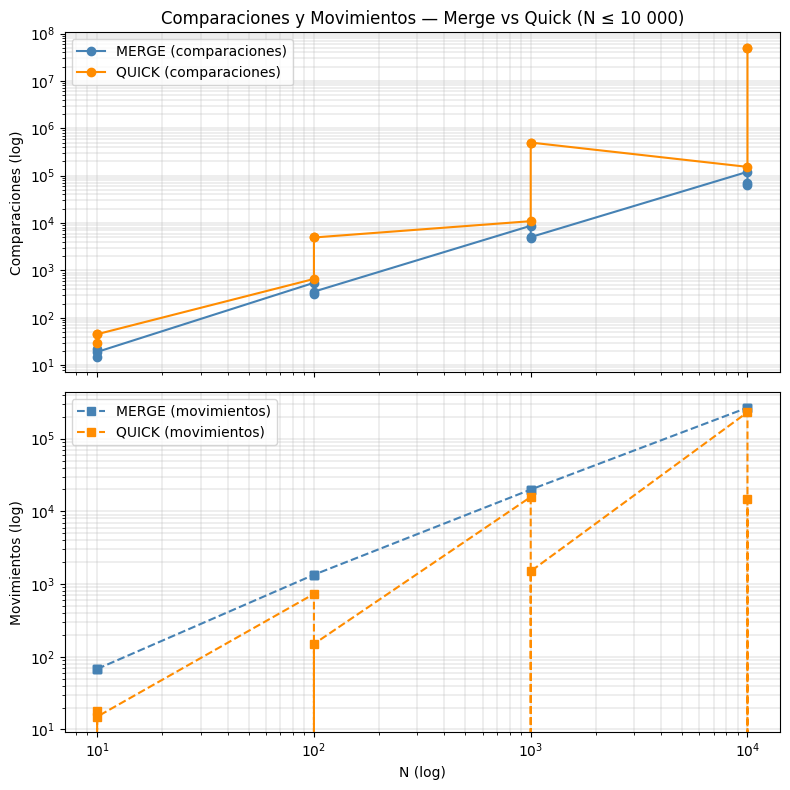

In [4]:
# sort_bench_py.py — Bench Merge vs Quick (hasta 10 000) con UNA figura (2 subplots)
import sys, random, time
import matplotlib.pyplot as plt

DEFAULT_FILE = "numeros.txt"
# Tamaños evaluados (máximo 10 000)
NS = [10, 100, 1_000, 10_000]
MAX_N = 10_000

BASE_SEED = 1469598103

class Metrics:
    __slots__ = ("comps", "moves")
    def __init__(self): self.comps = 0; self.moves = 0

def reversed_copy(a): return list(reversed(a))
def shuffled_copy(a, seed):
    b = a[:]; rnd = random.Random(seed)
    for i in range(len(b) - 1, 0, -1):
        j = rnd.randint(0, i)
        b[i], b[j] = b[j], b[i]
    return b

# -------- Merge Sort (conteo) --------
def mergesort_count(a, mt: Metrics):
    n = len(a); aux = [0]*n
    def merge(l, m, r):
        i, j, k = l, m, l
        while i < m and j < r:
            mt.comps += 1
            if a[i] <= a[j]: aux[k] = a[i]; k += 1; i += 1; mt.moves += 1
            else:            aux[k] = a[j]; k += 1; j += 1; mt.moves += 1
        while i < m: aux[k] = a[i]; k += 1; i += 1; mt.moves += 1
        while j < r: aux[k] = a[j]; k += 1; j += 1; mt.moves += 1
        for t in range(l, r): a[t] = aux[t]; mt.moves += 1
    def rec(l, r):
        if r - l <= 1: return
        m = l + ((r - l) >> 1)
        rec(l, m); rec(m, r); merge(l, m, r)
    rec(0, n)

# -------- Quick Sort (Lomuto iterativo, pivote final) --------
def quicksort_count(a, mt: Metrics):
    n = len(a)
    if n == 0: return
    def partition(lo, hi):
        pivot = a[hi]; i = lo
        for j in range(lo, hi):
            mt.comps += 1
            if a[j] <= pivot:
                if i != j: a[i], a[j] = a[j], a[i]; mt.moves += 3
                i += 1
        if i != hi: a[i], a[hi] = a[hi], a[i]; mt.moves += 3
        return i
    stack = [(0, n-1)]
    while stack:
        lo, hi = stack.pop()
        if lo >= hi: continue
        p = partition(lo, hi)
        left = (lo, p-1); right = (p+1, hi)
        big, small = (left, right) if (p-1-lo) > (hi-(p+1)) else (right, left)
        stack.append(big); stack.append(small)

# -------- Entrada --------
def load_ints(path, limit=None):
    data = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for tok in f.read().split():
            try:
                data.append(int(tok))
                if limit and len(data) >= limit: break
            except ValueError:
                pass
    return data

def parse_positional_args(argv):
    pos = [a for a in argv[1:] if not a.startswith("-")]
    if len(pos) >= 1:
        path = pos[0]
        limit = int(pos[1]) if len(pos) >= 2 else None
    else:
        path = DEFAULT_FILE
        limit = None
    return path, limit

# -------- Benchmark + Figura --------
def main():
    path, limit = parse_positional_args(sys.argv)
    if limit is None or limit > MAX_N: limit = MAX_N

    base_all = load_ints(path, limit)
    if not base_all:
        print(f"No se pudo leer ningún entero de '{path}'.")
        sys.exit(1)

    base_sorted = sorted(base_all)
    L = len(base_sorted)
    Ns = [n for n in NS if n <= L and n <= MAX_N]
    if not Ns:
        print("No hay tamaños N válidos para los datos cargados."); sys.exit(1)

    results = []
    print("N        | CASO  | ALGORITMO | COMPARACIONES | MOVES      | TIEMPO (ms)")
    print("-----------------------------------------------------------------------")

    for n in Ns:
        asc = base_sorted[:n]
        desc = reversed_copy(asc)
        medium = shuffled_copy(asc, BASE_SEED ^ n)

        for caso, arr_src in [("MEDIO", medium), ("MEJOR", asc), ("PEOR", desc)]:
            for alg, sort_fun in [("MERGE", mergesort_count), ("QUICK", quicksort_count)]:
                arr = arr_src[:]; mt = Metrics()
                t0 = time.perf_counter(); sort_fun(arr, mt)
                ms = (time.perf_counter()-t0)*1000
                results.append({"N": n, "caso": caso, "alg": alg,
                                "comps": mt.comps, "moves": mt.moves, "ms": ms})
                print(f"{n:<8} | {caso:<5} | {alg:<8} | {mt.comps:<13} | {mt.moves:<10} | {ms:.3f}")
        print("-----------------------------------------------------------------------")

    # -------- Figura con 2 subplots --------
    def pick(series, alg=None, key="comps"):
        X, Y = [], []
        for r in series:
            if r["alg"] == alg:
                X.append(r["N"]); Y.append(r[key])
        return X, Y

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 8))
    colors = {"MERGE": "steelblue", "QUICK": "darkorange"}

    for alg in ("MERGE", "QUICK"):
        Xc, Yc = pick(results, alg=alg, key="comps")
        Xm, Ym = pick(results, alg=alg, key="moves")
        ax1.plot(Xc, Yc, "o-", color=colors[alg], label=f"{alg} (comparaciones)")
        ax2.plot(Xm, Ym, "s--", color=colors[alg], label=f"{alg} (movimientos)")

    for ax in (ax1, ax2):
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.grid(True, which="both", linewidth=0.3)
        ax.legend()

    ax1.set_ylabel("Comparaciones (log)")
    ax2.set_xlabel("N (log)")
    ax2.set_ylabel("Movimientos (log)")
    ax1.set_title("Comparaciones y Movimientos — Merge vs Quick (N ≤ 10 000)")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
